# Monte Carlo (MC) vs. Diferencia Temporal (TD)

En este notebook resolvemos un problema básico de evaluación de política con dos métodos *model-free*:

- **Monte Carlo (MC)**: aprende cuando termina el episodio.
- **Diferencia Temporal (TD)**: aprende paso a paso, sin esperar el final.

## Problema
Estimaremos el valor de estados en un entorno simple (**Random Walk**). El valor responde:
> “Si sigo la política fija, ¿qué tan probable es terminar en la meta con recompensa 1?”

En este entorno la recompensa ocurre solo al final, así que el valor coincide con probabilidad de éxito.


## 1) Entorno: Random Walk

- Estados no terminales: **1,2,3,4,5**
- Terminales: **0** (izquierda) y **6** (derecha)
- Inicio: estado **3**
- Política fija: LEFT/RIGHT con prob. 0.5
- Recompensa: **1** si llegas a 6, **0** si llegas a 0

Valores verdaderos (bajo esta política) ≈ **[1/6, 2/6, 3/6, 4/6, 5/6]** para estados 1..5.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)


In [2]:
class RandomWalkEnv:
    """Random Walk minimalista (0..6)."""
    def __init__(self):
        self.start_state = 3
        self.left_terminal = 0
        self.right_terminal = 6
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        assert action in ["LEFT", "RIGHT"]
        next_state = self.state - 1 if action == "LEFT" else self.state + 1

        if next_state == self.right_terminal:
            reward, done = 1.0, True
        elif next_state == self.left_terminal:
            reward, done = 0.0, True
        else:
            reward, done = 0.0, False

        self.state = next_state
        return next_state, reward, done

env = RandomWalkEnv()
env.reset()


3

In [3]:
def random_policy(state):
    # Política fija (misma para MC y TD): izquierda/derecha con 0.5
    return random.choice(["LEFT", "RIGHT"])

def generate_episode(env, policy_fn, max_steps=100):
    """Devuelve una lista de transiciones (s, a, r, s_next, done)."""
    s = env.reset()
    traj = []
    for t in range(max_steps):
        a = policy_fn(s)
        s_next, r, done = env.step(a)
        traj.append((s, a, r, s_next, done))
        s = s_next
        if done:
            break
    return traj

# Ejemplo: un episodio para inspeccionar
demo = generate_episode(RandomWalkEnv(), random_policy)
pd.DataFrame(demo, columns=["s","a","r","s_next","done"])


,s,a,r,s_next,done
0,3,RIGHT,0.0,4,False
1,4,LEFT,0.0,3,False
2,3,RIGHT,0.0,4,False
3,4,LEFT,0.0,3,False
4,3,LEFT,0.0,2,False
5,2,LEFT,0.0,1,False
6,1,RIGHT,0.0,2,False
7,2,LEFT,0.0,1,False
8,1,LEFT,0.0,0,True


## 2) Valores verdaderos (referencia)

Los usamos para medir error. (Aquí son conocidos analíticamente.)


In [4]:
true_V = {s: s/6 for s in [1,2,3,4,5]}
pd.Series(true_V, name="V verdadero")


,V verdadero
1,0.166667
2,0.333333
3,0.500000
4,0.666667
5,0.833333


## 3) Monte Carlo (MC)

Idea operativa:
1. Corre un episodio completo.
2. Si un estado aparece en el episodio, calcula el retorno desde ahí (en este entorno: 0 o 1).
3. Actualiza V(s) **después** del episodio.

En esta versión didáctica usamos actualización incremental con `alpha`.


In [5]:
def mc_prediction(env, policy_fn, alpha=0.05, episodes=1000):
    # Inicializamos en 0.5 (neutral)
    V = {s: 0.5 for s in [1,2,3,4,5]}

    for _ in range(episodes):
        traj = generate_episode(env, policy_fn)

        # En este entorno, el retorno total del episodio es 0 o 1 (la recompensa final).
        G_episode = sum(r for (_,_,r,_,_) in traj)

        # Every-visit MC: actualizamos cada estado visitado (no terminal)
        visited_states = [s for (s,_,_,_,_) in traj if s in V]
        for s in visited_states:
            V[s] = V[s] + alpha * (G_episode - V[s])
    return V

V_mc = mc_prediction(RandomWalkEnv(), random_policy, alpha=0.05, episodes=2000)
pd.Series(V_mc, name="V por MC")


,V por MC
1,0.206986
2,0.486217
3,0.709243
4,0.823257
5,0.894682


## 4) Diferencia Temporal (TD)

Idea operativa:
1. Camina un paso (s → s_next) y observa recompensa inmediata.
2. Actualiza V(s) **en ese momento** usando también tu estimación de V(s_next).
3. Repite hasta terminar el episodio.

Aquí, si s_next es terminal, usamos V(s_next)=0.


In [6]:
def td0_prediction(env, policy_fn, alpha=0.05, episodes=1000):
    V = {s: 0.5 for s in [1,2,3,4,5]}

    for _ in range(episodes):
        s = env.reset()
        done = False
        while not done:
            a = policy_fn(s)
            s_next, r, done = env.step(a)

            if s in V:
                v_next = V[s_next] if s_next in V else 0.0
                target = r + v_next  # gamma=1 aquí
                V[s] = V[s] + alpha * (target - V[s])

            s = s_next
    return V

V_td = td0_prediction(RandomWalkEnv(), random_policy, alpha=0.05, episodes=2000)
pd.Series(V_td, name="V por TD(0)")


,V por TD(0)
1,0.199281
2,0.321828
3,0.503943
4,0.691158
5,0.867660


## 5) Comparación con curva de aprendizaje (error RMS)

Medimos qué tan lejos está V estimado del V verdadero a lo largo de episodios.


In [7]:
def rms_error(V_est, true_V):
    return float(np.sqrt(np.mean([(V_est[s]-true_V[s])**2 for s in true_V])))

def learning_curve(method, alpha=0.05, episodes=200, seed=123):
    random.seed(seed)
    np.random.seed(seed)

    env = RandomWalkEnv()
    V = {s: 0.5 for s in [1,2,3,4,5]}
    errors = []

    for ep in range(episodes):
        if method == "MC":
            traj = generate_episode(env, random_policy)
            G_episode = sum(r for (_,_,r,_,_) in traj)
            for (s,_,_,_,_) in traj:
                if s in V:
                    V[s] = V[s] + alpha * (G_episode - V[s])
        elif method == "TD":
            s = env.reset()
            done = False
            while not done:
                a = random_policy(s)
                s_next, r, done = env.step(a)
                if s in V:
                    v_next = V[s_next] if s_next in V else 0.0
                    target = r + v_next
                    V[s] = V[s] + alpha * (target - V[s])
                s = s_next
        else:
            raise ValueError("method debe ser 'MC' o 'TD'")

        errors.append(rms_error(V, true_V))

    return errors




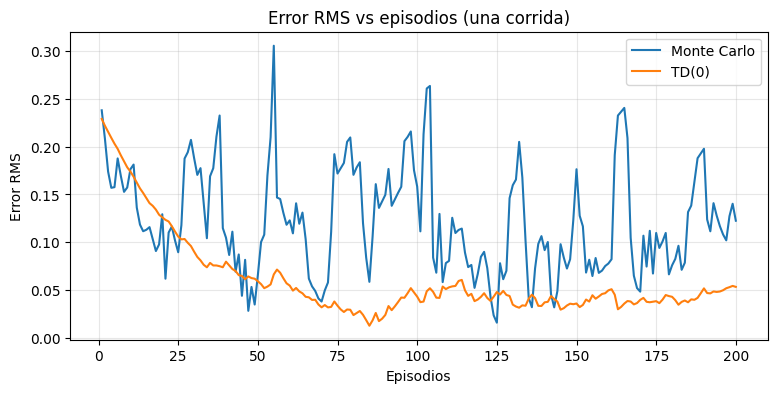

In [8]:
episodes = 200
alpha = 0.05
err_mc = learning_curve("MC", alpha=alpha, episodes=episodes, seed=1)
err_td = learning_curve("TD", alpha=alpha, episodes=episodes, seed=1)

plt.figure(figsize=(9,4))
plt.plot(range(1, episodes+1), err_mc, label="Monte Carlo")
plt.plot(range(1, episodes+1), err_td, label="TD(0)")
plt.title("Error RMS vs episodios (una corrida)")
plt.xlabel("Episodios")
plt.ylabel("Error RMS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6) Tabla comparativa final

Entrenamos ambos métodos y comparamos con la referencia.


In [9]:
episodes = 5000
alpha = 0.05
V_mc = mc_prediction(RandomWalkEnv(), random_policy, alpha=alpha, episodes=episodes)
V_td = td0_prediction(RandomWalkEnv(), random_policy, alpha=alpha, episodes=episodes)

df = pd.DataFrame({
    "V verdadero": [true_V[s] for s in [1,2,3,4,5]],
    "V MC":        [V_mc[s]   for s in [1,2,3,4,5]],
    "V TD(0)":     [V_td[s]   for s in [1,2,3,4,5]],
}, index=[1,2,3,4,5])

df


,V verdadero,V MC,V TD(0)
1,0.166667,0.121219,0.167993
2,0.333333,0.203479,0.318504
3,0.500000,0.442677,0.480946
4,0.666667,0.686332,0.656185
5,0.833333,0.872193,0.847301
